In [2]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately    

In [3]:
load_dotenv()


True

In [5]:
model = ChatGroq(model="openai/gpt-oss-120b")

In [6]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last", # remove the last big chunk of messages
        token_counter=count_tokens_approximately,
        max_tokens= 150 
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [8]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

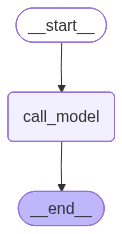

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is baapo ka baap bhavya."}]},config)

result["messages"][-1].content

Current Token Count -> 13
Hi, my name is baapo ka baap bhavya.


'Hello! Nice to meet you,\u202fbaapo\u202fka\u202fbaap\u202fbhavya. How can I assist you today?'

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 47
Hi, my name is baapo ka baap bhavya.
Hello! Nice to meet you, baapo ka baap bhavya. How can I assist you today?
I am learning LangGraph.


'That’s great! LangGraph is a powerful framework for building **composable, state‑driven LLM applications** (think “graph‑based workflows” for language models). Below is a quick starter guide to get you up and running, plus some tips and resources for deeper dives.\n\n---\n\n## 1️⃣ Core Concepts at a Glance\n\n| Concept | What It Is | Why It Matters |\n|---------|------------|----------------|\n| **Node** | A single “step” in the graph – e.g., a prompt, a tool call, a transformation, or a custom Python function. | Encapsulates a reusable piece of logic. |\n| **Edge** | Directed connection that determines the **next node** based on the current state (or output). | Gives you conditional branching, loops, and parallelism. |\n| **State** | A mutable dictionary (`dict`) that travels with the graph, storing inputs, intermediate results, and metadata. | Enables context sharing across nodes without global variables. |\n| **Graph** | The full DAG (or cyclic graph) of nodes & edges, usually defi

In [ ]:
#trimming performed thats why the token count is 13 in output
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'### Short‑Term Memory (STM) – A Quick Overview\n\n**Short‑term memory** is the brain’s “scratch‑pad” for holding information for a brief period—typically a few seconds to a minute—while you’re using it. It lets you keep a phone number in mind long enough to dial it, remember the last word someone just said, or follow a short set of instructions.\n\n---\n\n## 1. Core Features\n\n| Feature | What It Means |\n|---------|----------------|\n| **Capacity** | Roughly **7\u202f±\u202f2 items** (Miller’s classic finding). In practice, most people can hold about **4–5 chunks** of information at once. |\n| **Duration** | Without rehearsal, the contents fade in **≈15–30\u202fseconds**. With active rehearsal (repeating it silently or aloud), the information can be kept longer. |\n| **Encoding** | Primarily **acoustic/phonological** (sound‑based) for most people, though visual or semantic codes can also be used. |\n| **Retrieval** | Items are retrieved quickly because they are still “online” in the